In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [6]:
import pickle
import pandas as pd

#Load pickles for FC and CxtA
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxta_allmice.pkl', 'rb') as file:
    collection_cxta = pickle.load(file)

In [7]:
collection_cxta.animals

{'astroF3': <onep.onephoton.InscopixProcessing at 0x7f8c00d828c0>,
 'astroF5': <onep.onephoton.InscopixProcessing at 0x7f8bd2339de0>,
 'astroF6': <onep.onephoton.InscopixProcessing at 0x7f8bf3590d60>,
 'astroF7': <onep.onephoton.InscopixProcessing at 0x7f8bf3591de0>,
 'astroF8': <onep.onephoton.InscopixProcessing at 0x7f8bf3592e60>,
 'astroF9': <onep.onephoton.InscopixProcessing at 0x7f8bf3593ee0>,
 'astroF10': <onep.onephoton.InscopixProcessing at 0x7f8bf35ccfa0>,
 'astroM3': <onep.onephoton.InscopixProcessing at 0x7f8bf35ce020>,
 'astroM4': <onep.onephoton.InscopixProcessing at 0x7f8bf35cf0a0>,
 'astroM5': <onep.onephoton.InscopixProcessing at 0x7f8bf35f8160>,
 'astroM10': <onep.onephoton.InscopixProcessing at 0x7f8bf35f91e0>}

In [37]:
#Grab data for number of cells on each day and across days - plotted in Fig 1
#Select your animal
animal = 'astroF10'

#Get reg table for animal FC-A; this is FC to CxtA only mapped
reg_table = collection_fc.animals[animal].get_registration_table()
reg_pairs = reg_table["FC-HAB"]

#Convert to a data frame so I can see things
reg_df_filtered = pd.DataFrame(reg_pairs, columns=['fc_index', 'cxta_index'])

#Grab rejected_inds for FC and A from object
# rejected_fc = collection_fc.animals[animal].rejected_inds
# rejected_cxta = collection_cxta.animals[animal].rejected_inds
#
# #Filter by rejected indices from both sessions (the traces were deemed unwell)
# reg_df_filtered = reg_df[
#     (~reg_df['fc_index'].isin(rejected_fc)) & (~reg_df['cxta_index'].isin(rejected_cxta))
# ]

#Define your groups of interest
#"reactivated" or "active across days"
registered_both = reg_df_filtered[
    (reg_df_filtered['fc_index'] != -1) & (reg_df_filtered['cxta_index'] != -1)
]

#fc only cells
unique_fc_only = reg_df_filtered[
    (reg_df_filtered['fc_index'] != -1) & (reg_df_filtered['cxta_index'] == -1)
]

#cxtA only cells
unique_cxta_only = reg_df_filtered[
    (reg_df_filtered['fc_index'] == -1) & (reg_df_filtered['cxta_index'] != -1)
]

# number ofc ells in each category
n_fc_only = len(unique_fc_only)
n_cxta_only = len(unique_cxta_only)
n_both = len(registered_both)

total_unique_cells = n_fc_only + n_cxta_only + n_both

#Print your results
print(f"Animal: {animal}")
print(f"Total registered cells across both sessions: {len(registered_both)}")
print(f"Accepted cells unique to FC: {len(unique_fc_only)}")
print(f"Accepted cells unique to CxtA: {len(unique_cxta_only)}")
print(f"Total unique cells: {total_unique_cells}")

Animal: astroF10
Total registered cells across both sessions: 50
Accepted cells unique to FC: 154
Accepted cells unique to CxtA: 56
Total unique cells: 260


In [ ]:
#Want to plot

In [337]:
fc_active = fc_traces[both_idxs[0]]
fc_active

array([[-0.00036864, -0.00787927, -0.00304559, ..., -0.00070377,
         0.00123832, -0.00352497],
       [-0.00097942,  0.00295194, -0.00155795, ..., -0.00356344,
        -0.00323586, -0.00078162],
       [ 0.00286598,  0.00433902, -0.00200361, ...,  0.00041963,
        -0.00488633,  0.00528635],
       [-0.00396538, -0.0001503 , -0.00015082, ..., -0.00372927,
         0.00550393,  0.00104456],
       [-0.00477107, -0.00413356, -0.00833448, ..., -0.00196339,
         0.00414645, -0.00571847],
       [ 0.00121708, -0.00197074, -0.00553788, ...,  0.00210244,
        -0.00707204, -0.008598  ]])

In [338]:
recall_active = recall_traces[both_idxs[1]]
recall_active

array([[ 0.00526641,  0.00796767,  0.00271103, ...,  0.0013192 ,
        -0.00567341, -0.01849394],
       [ 0.0077929 , -0.00021136, -0.00277348, ...,  0.00341316,
         0.0028909 ,  0.00213484],
       [-0.00328677,  0.00228768, -0.00305239, ..., -0.00908592,
        -0.01386142, -0.00592009],
       [ 0.00871803,  0.00050127,  0.00536598, ..., -0.0003817 ,
        -0.00231159, -0.00386243],
       [-0.00996938, -0.00606177, -0.00645857, ..., -0.00068089,
        -0.00649953, -0.01318604],
       [-0.0138329 , -0.01457288, -0.00706833, ..., -0.00095374,
        -0.00214752, -0.00141574]])

In [339]:
fc_dfz = stats.zscore(fc_active, axis=1)


In [340]:
recall_dfz = stats.zscore(recall_active, axis=1)


In [341]:
fc_dfz = fc_dfz[:,:3303]
fc_dfz

array([[-0.02916976, -0.62347265, -0.24099246, ..., -0.40620838,
        -0.39484596, -0.41048835],
       [-0.13405252,  0.40403222, -0.21323726, ..., -0.27525606,
         0.37710032,  0.15695838],
       [ 0.38643332,  0.58505153, -0.27015606, ..., -0.1751556 ,
        -0.32786862, -0.5512386 ],
       [-0.66572764, -0.02523283, -0.02532055, ..., -0.13204687,
         0.40325667, -0.01118092],
       [-0.44114221, -0.38219725, -0.77062208, ..., -0.39962022,
        -0.41705827, -0.32952324],
       [ 0.1978227 , -0.32032143, -0.90011778, ..., -0.85916465,
        -0.34154941,  0.11488067]])

In [342]:
recall_dfz = recall_dfz[:,:3303]
recall_dfz

array([[ 0.78193134,  1.18300007,  0.40252023, ...,  0.19586832,
        -0.84235995, -2.74588905],
       [ 1.04850257, -0.02843738, -0.37316051, ...,  0.4592261 ,
         0.3889578 ,  0.28723418],
       [-0.16179376,  0.11261254, -0.15025589, ..., -0.44726103,
        -0.68233834, -0.29142058],
       [ 1.52320411,  0.08758047,  0.93753808, ..., -0.0666908 ,
        -0.40387885, -0.67483934],
       [-1.22393856, -0.74420205, -0.79291723, ..., -0.08359268,
        -0.79794589, -1.61884752],
       [-1.36579526, -1.43885739, -0.69789394, ..., -0.0941676 ,
        -0.21203569, -0.13978358]])

In [343]:
across_eta_, time = onep.eta_individual_cells(
    data=fc_dfz,
    timestamps=collection_cxta_fc.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300], ],  #detected onsets
    window=28
)

In [344]:
across_eta_R, time_R = onep.eta_individual_cells(
    data=recall_dfz,
    timestamps=collection_cxta_recall.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[67.54823800666061, 111.5145467683924, 143.0903503336361], ],  #detected onsets
    window=28
)

#astro3 - 71.9448772796669, 224.9276649396253, 266.7955865787648

#astro4-121.5068386007773, 171.4685321043864, 243.9129876846197,
       #285.4811166796225

#astro5 - 34.67342136063298, 89.83114064325375, 173.8667238256524

#astro6 - 84.73501601221373,  148.286278021374, 174.9658172610687,
       #266.6954690290077

#astro7 - 43.16693610899183,  118.509227373297, 229.5241950054496,
       #266.8955702479564

#astro8 - 91.42997888754353,133.3978380490389,248.8094507431512,  275.489018352959

#astro9 - 67.54823800666061, 111.5145467683924, 143.0903503336361

In [92]:
# mu_fc = pd.read_csv("/Users/suthardr/Desktop/astrocyte_shot_Gaussian_noise3_origID.csv")
mu_fc = pd.read_csv("/Users/suthardr/Desktop/Rui_Newest_Model_July/astrocyte_shot_Gaussian_noise3.csv")
mu_fc

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
0,NaN,0.2,0.0,5.0,0.7,0.8,NaN,NaN,NaN,NaN,NaN,NaN,1,astro3,0
1,1.0,0.3,0.0,5.7,1.5,1.0,NaN,NaN,5.5,4.3,5.1,3.0,10,astro3,9
2,10.0,0.1,0.0,3.4,0.9,0.4,NaN,NaN,5.5,6.9,4.8,0.1,100,astro3,101
3,100.0,0.1,0.0,5.2,1.4,3.4,3.121298,5.725,3.1,3.2,3.6,17.7,1000,astro7,96
4,1000.0,0.0,0.0,28.8,0.8,5.4,7.616813,6.725,4.5,5.2,10.2,0.1,1001,astro7,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,995.0,0.1,0.0,5.2,0.7,2.7,2.879091,4.125,7.5,3.8,4.6,4.4,996,astro7,92
1509,996.0,0.0,0.0,12.2,2.6,8.4,9.527985,14.425,4.8,5.0,6.7,7.6,997,astro7,93
1510,997.0,0.2,0.0,6.1,2.2,2.8,2.617091,5.425,19.7,3.2,24.5,5.3,998,astro7,94
1511,998.0,0.1,0.0,4.9,3.1,0.2,0.496655,5.100,4.0,2.5,8.1,3.7,999,astro7,95


In [93]:
animal_to_filter = [animal]

# Use .isin() to filter the DataFrame
mu_fc_animal = mu_fc[mu_fc['animal'].isin(animal_to_filter)]

In [95]:
# Filter load_reg_table based on rejected_indices in column 0
mu_fc_filtered = mu_fc_animal[mu_fc_animal['orig_index'].isin(both_idxs[0])]
mu_fc_filtered

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
471,1421.0,0.2,0.0,3.9,1.1,0.2,0.236291,3.825,4.5,4.5,4.6,4.3,1422,astro9,24
473,1423.0,0.1,0.0,4.5,1.2,1.2,0.942956,4.425,3.5,3.6,3.5,4.4,1424,astro9,26
486,1435.0,0.1,0.0,3.1,0.7,0.3,0.310913,3.050,2.0,1.9,1.9,3.8,1436,astro9,38
496,1444.0,0.1,0.0,3.0,0.6,0.4,0.294392,3.000,1.7,2.4,2.6,3.7,1445,astro9,47
508,1455.0,0.1,0.0,3.6,1.1,0.8,0.694622,3.525,3.6,3.8,3.9,2.1,1456,astro9,58
525,1470.0,0.1,0.0,3.9,1.4,0.1,0.150000,3.825,2.6,2.9,3.4,7.5,1471,astro9,74


In [96]:
mu_r = pd.read_csv("/Users/suthardr/Desktop/Rui_Newest_Model_July/astrocyte_recall_Gaussian_noise3_origID.csv")
mu_r

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
0,1,0.05,0.01,16.94,11.46,0.44,1.08,16.90,17.2,17.8,15.7,NaN,1,astro3,0
1,2,0.11,0.01,13.52,2.82,6.64,4.94,16.67,18.0,11.2,20.8,NaN,10,astro3,10
2,3,0.19,0.01,14.64,2.52,4.49,5.03,16.20,11.5,21.5,15.6,NaN,100,astro3,146
3,4,0.02,0.00,10.04,1.81,6.22,6.43,7.78,14.3,0.7,4.1,12.0,1000,astro8,22
4,5,0.18,0.01,4.28,0.09,5.63,3.05,8.57,11.8,8.1,4.6,9.8,1001,astro8,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278,1279,0.02,0.01,7.03,2.89,6.21,5.72,6.95,11.1,12.6,2.7,1.4,995,astro8,17
1279,1280,0.06,0.01,25.31,10.27,2.28,2.07,25.68,27.6,27.2,23.3,24.6,996,astro8,18
1280,1281,0.05,0.01,15.28,2.04,9.26,11.92,10.85,17.0,1.7,24.6,0.1,997,astro8,19
1281,1282,0.02,0.01,15.95,4.97,6.27,9.29,14.17,17.4,11.7,24.8,2.8,998,astro8,20


In [97]:
# Use .isin() to filter the DataFrame
mu_r_animal = mu_r[mu_r['animal'].isin(animal_to_filter)]
mu_r_animal

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
230,231,0.02,0.01,14.40,0.65,8.87,7.76,15.03,6.1,20.1,18.9,NaN,1205,astro9,0
231,232,0.43,0.01,3.39,2.58,2.31,2.87,2.77,5.8,0.1,2.4,NaN,1206,astro9,1
232,233,0.29,0.01,7.94,2.86,0.15,0.15,8.07,8.1,7.9,8.2,NaN,1207,astro9,2
233,234,0.05,0.01,7.57,2.55,2.74,1.46,8.53,9.9,7.0,8.7,NaN,1208,astro9,3
234,235,0.01,0.01,17.57,6.05,1.84,4.25,20.20,24.4,20.3,15.9,NaN,1209,astro9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,312,0.02,0.01,22.46,6.96,9.58,13.41,18.17,2.7,25.2,26.6,NaN,1279,astro9,75
313,314,0.09,0.01,17.63,7.18,1.16,0.38,18.47,18.9,18.3,18.2,NaN,1280,astro9,76
314,315,0.07,0.01,5.57,4.09,4.34,5.16,4.77,2.9,0.8,10.6,NaN,1281,astro9,77
315,316,0.02,0.00,17.96,10.48,8.26,2.84,17.77,14.7,18.3,20.3,NaN,1282,astro9,78


In [98]:
# Filter load_reg_table based on rejected_indices in column 0
mu_r_filtered = mu_r_animal[mu_r_animal['orig_index'].isin(both_idxs[1])]
mu_r_filtered

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index
236,237,0.07,0.01,7.42,2.51,4.18,13.10,15.07,5.1,29.9,10.2,NaN,1210,astro9,5
240,241,0.41,0.01,7.51,2.15,1.58,1.64,7.93,9.8,6.7,7.3,NaN,1214,astro9,9
241,242,0.11,0.01,3.39,1.80,1.91,1.33,3.27,4.8,2.5,2.5,NaN,1215,astro9,10
251,252,0.07,0.01,3.44,3.92,9.22,15.68,11.90,1.2,4.6,29.9,NaN,1224,astro9,20
261,262,0.05,0.01,13.82,0.85,10.44,14.62,19.63,2.9,29.9,26.1,NaN,1233,astro9,29
293,294,0.16,0.01,8.59,5.00,0.37,0.06,8.03,8.0,8.1,8.0,NaN,1262,astro9,58


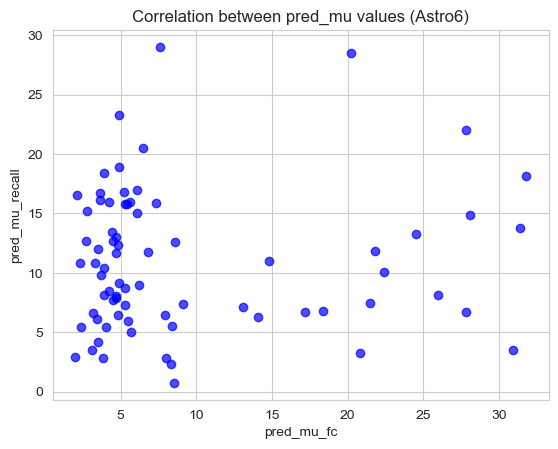

In [533]:
plt.scatter(mu_fc_filtered['pred_mu'],mu_r_filtered['pred_mu'], color='blue', alpha=0.7)
plt.title('Correlation between pred_mu values (Astro6)')
plt.xlabel('pred_mu_fc')
plt.ylabel('pred_mu_recall')
plt.grid(True)
plt.savefig("/Users/suthardr/Desktop/Rui_models/astro6_mode.svg")

In [ ]:
#Reactivated cells during CFC, sorted on CFC
# max_idxs = np.zeros(95)  #change based on # of overlapping cells
# for i in range(across_eta_.shape[0]):
#     idx = np.argmax(across_eta_[i])
#     max_idxs[i] = idx
# new_table = np.hstack((both_idxs, max_idxs.reshape(-1, 1)))
# fc_idxs = np.argsort(new_table[:, 2])
# ###################
# sorted_arr_fc = across_eta_[fc_idxs] #across_eta (FC) traces at shock sorted by fc_argmax
#
# fig, ax = plt.subplots()
# ax.axvline((time.shape[0]/3), linestyle='--', color='white')
# sns.heatmap(sorted_arr_fc, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
# ax.set_xticks(np.linspace(0, sorted_arr_fc.shape[1], 5), np.linspace(np.min(time), np.max(time), 5))
# ax.set_title('FC Sorted Argmax: Reactivated Cells Only (Astro3)')
# ax.set_xlabel('Time (seconds)')
# ax.set_ylabel('Cell #')
# #fig.savefig('/Users/suthardr/Desktop/Reactivated_Cells_Plots/Astro3_reactivatedcells_fc_fc_sorted.png')

In [ ]:
# #Reactivated cells during Recall sorted on CFC
# max_idxs = np.zeros(95)  #change based on # of overlapping cells
# for i in range(across_eta_.shape[0]):
#     idx = np.argmax(across_eta_[i])
#     max_idxs[i] = idx
# new_table = np.hstack((both_idxs, max_idxs.reshape(-1, 1)))
# fc_idxs = np.argsort(new_table[:, 2])
# ###################
# sorted_arr_recall = across_eta_R[fc_idxs] #plot just the eta times
#
# fig, ax = plt.subplots()
# ax.axvline((time_R.shape[0]/3), linestyle='--', color='white')
# sns.heatmap(sorted_arr_recall, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
# ax.set_xticks(np.linspace(0, sorted_arr_recall.shape[1], 5), np.linspace(np.min(time_R), np.max(time_R), 5))
# ax.set_title('Recall Sorted FC Argmax: Reactivated Cells Only (Astro3)')
# ax.set_xlabel('Time (seconds)')
# ax.set_ylabel('Cell #')


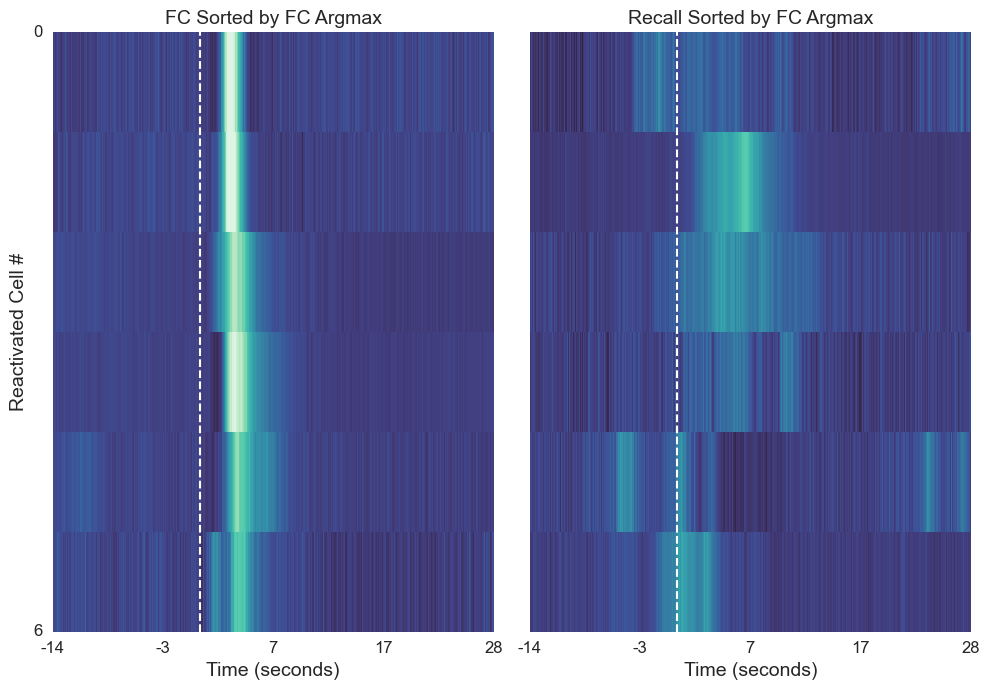

In [351]:
#Argmax sort - recall on FC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

max_idxs = np.zeros(95)  #change based on # of overlapping cells
for i in range(across_eta_.shape[0]):
    idx = np.argmax(across_eta_[i])
    max_idxs[i] = idx
new_table = np.hstack((both_idxs, max_idxs.reshape(-1, 1)))
fc_idxs = np.argsort(new_table[:, 2])
###################
sorted_arr_fc = across_eta_[fc_idxs] #across_eta (FC) traces at shock sorted by fc_argmax
sorted_arr_recall = across_eta_R[fc_idxs] #plot just the eta times

# Extract first and last index for y-axis ticks
first_last_fc = [0, sorted_arr_fc.shape[0]]
first_last_recall = [0, sorted_arr_recall.shape[0]]

# Set up FacetGrid for plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 7),sharey= True)  # Adjust figsize as needed

# Plot the FC sorted heatmap
sns.heatmap(sorted_arr_fc, cmap='mako', cbar=False, ax=axs[0], vmin=-3, vmax=6, annot=False)
axs[0].axvline((time.shape[0] / 3), linestyle='--', color='white')
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].set_xticks(np.linspace(0, sorted_arr_fc.shape[1], 5))
axs[0].set_xticklabels(np.linspace(np.min(time), np.max(time), 5).astype(int), rotation=0)
axs[0].set_yticks(first_last_fc)  # Set y-ticks to first and last indices
axs[0].set_yticklabels([first_last_fc[0], first_last_fc[1]], rotation=0)  # Label y-ticks
axs[0].set_title('FC Sorted by FC Argmax', fontsize=14)
axs[0].set_xlabel('Time (seconds)', fontsize=14)
axs[0].set_ylabel('Reactivated Cell #', fontsize=14)

# Plot the Recall sorted heatmap
heatmap = sns.heatmap(sorted_arr_recall, cmap='mako', cbar=False, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"}, ax=axs[1], vmin=-3, vmax=6, annot=False)
axs[1].axvline((time_R.shape[0] / 3), linestyle='--', color='white')
axs[1].tick_params(axis='both', which='major', labelsize=12)
axs[1].set_xticks(np.linspace(0, sorted_arr_recall.shape[1], 5))
axs[1].set_xticklabels(np.linspace(np.min(time_R), np.max(time_R), 5).astype(int), rotation=0)
axs[1].set_yticks(first_last_recall)  # Set y-ticks to first and last indices
axs[1].set_yticklabels([first_last_recall[0], first_last_recall[1]], rotation=0)  # Label y-ticks
axs[1].set_title('Recall Sorted by FC Argmax', fontsize=14)
axs[1].set_xlabel('Time (seconds)', fontsize=14)

# Get the current colorbar object from the heatmap
# cbar = heatmap.collections[0].colorbar
#
# # Set font size for colorbar labels
# cbar.ax.yaxis.set_tick_params(labelsize=12)
# cbar.set_label(r"z-scored $\frac{dF}{F}$", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/Rui_Newest_Model_July/Recall_sorted_FC_argmax/astro9_reactivated_sort_sequence_correct.png')

In [264]:
max_idxs_fc = np.zeros(sorted_arr_fc.shape[0], dtype=int)

# # Iterate over each row of across_eta_ to find the maximum index
for i in range(sorted_arr_fc.shape[0]):
    idx = np.argmax(sorted_arr_fc[i])
    max_idxs_fc[i] = idx

# Now, use max_idxs to index into the time array
argmax_fc = time[max_idxs_fc]
argmax_fc

array([-13.89976134,  -8.18615752,  -7.88544153,  -7.18377088,
        -3.17422434,   1.53699284,   1.73747017,   1.73747017,
         1.73747017,   1.83770883,   1.93794749,   1.93794749,
         2.03818616,   2.23866348,   2.33890215,   2.33890215,
         2.43914081,   2.43914081,   2.53937947,   2.53937947,
         2.53937947,   2.63961814,   2.63961814,   2.63961814,
         2.63961814,   2.7398568 ,   2.7398568 ,   2.7398568 ,
         2.7398568 ,   2.7398568 ,   2.84009547,   2.84009547,
         2.84009547,   2.84009547,   2.94033413,   2.94033413,
         2.94033413,   2.94033413,   2.94033413,   2.94033413,
         2.94033413,   2.94033413,   2.94033413,   3.04057279,
         3.14081146,   3.14081146,   3.14081146,   3.14081146,
         3.14081146,   3.14081146,   3.14081146,   3.14081146,
         3.24105012,   3.24105012,   3.34128878,   3.34128878,
         3.34128878,   3.34128878,   3.34128878,   3.34128878,
         3.44152745,   3.44152745,   3.44152745,   3.54

In [265]:
max_idxs_recall = np.zeros(sorted_arr_recall.shape[0], dtype=int)

# Iterate over each row of across_eta_ to find the maximum index
for i in range(sorted_arr_recall.shape[0]):
    idx = np.argmax(sorted_arr_recall[i])
    max_idxs_recall[i] = idx

argmax_recall = time_R[max_idxs_recall]
argmax_recall

array([ 1.53699284,  2.43914081,  1.43675418, -0.36754177, 15.3699284 ,
       -2.27207637,  7.150358  ,  0.93556086, -0.2673031 ,  2.23866348,
        2.03818616,  4.34367542,  0.33412888,  0.63484487,  6.0477327 ,
        1.23627685,  1.6372315 ,  8.65393795,  7.05011933,  3.14081146,
       10.05727924,  2.03818616,  2.7398568 ,  1.93794749,  2.94033413,
        3.74224344,  0.33412888,  8.25298329,  2.53937947,  4.54415274,
        1.93794749,  4.64439141,  6.24821002,  3.14081146,  0.33412888,
        4.84486874,  6.849642  ,  5.04534606,  3.64200477, -0.06682578,
        3.04057279,  2.94033413,  2.43914081,  2.23866348,  4.84486874,
        0.43436754,  5.84725537,  4.64439141,  2.03818616,  0.13365155,
        4.9451074 ,  7.05011933,  7.05011933,  4.9451074 ,  2.13842482,
        5.94749403,  1.6372315 ,  5.74701671, 21.58472554,  1.43675418,
        3.04057279,  3.24105012,  5.04534606,  4.84486874,  4.9451074 ,
        5.84725537,  5.34606205,  4.74463007,  2.13842482,  5.04

In [266]:
# #Run spearman's correlation on x and y
rho, p = stats.spearmanr(argmax_fc,argmax_recall, axis=0)

#print Spearman rank correlation and p-value
print(rho)
print(p)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
0.2828417189061091
0.0004955605683475164


In [171]:
#Pred_mu sort - recall on FC
# across_eta_

array([[ 0.34842874,  0.46924713,  0.60533933, ..., -0.31030309,
        -0.34330853, -0.38141049],
       [ 0.14282704,  0.11195662,  0.20951826, ..., -0.22606888,
        -0.14592381, -0.29586742],
       [-0.29266741, -0.2084846 , -0.35104262, ..., -0.34043845,
        -0.37411436, -0.4579726 ],
       ...,
       [-0.42813314, -0.65211228, -0.43463975, ..., -0.52716442,
        -0.67540911, -0.43554089],
       [ 0.55089638,  0.34924335,  0.26367116, ..., -0.29882004,
        -0.55014756, -0.45908599],
       [ 0.23572093,  0.1197066 , -0.48741184, ..., -0.19887093,
        -0.12594204,  0.02945085]])

In [162]:
mu_fc_filtered['across_eta_fc'] = across_eta_.tolist()
mu_fc_filtered['across_eta_recall'] = across_eta_R.tolist()

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_15607/3436777925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu_fc_filtered['across_eta_fc'] = across_eta_.tolist()
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_15607/3436777925.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu_fc_filtered['across_eta_recall'] = across_eta_R.tolist()


In [170]:
#predmu all FC cells
# mu_fc_animal['across_eta_fc'] = across_eta_.tolist()
# mu_fc_animal

ValueError: Length of values (95) does not match length of index (166)

In [1093]:
# sorted = mu_fc_filtered.sort_values(by='pred_mu')
# sorted

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,peak_mean,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index,across_eta_fc,across_eta_recall
1444,1445,0.1,0.0,3.0,0.6,0.4,0.294392,3.000,3.0,2.6,3.3,3.1,1445,astro9,47,"[-0.19857447489894373, -0.22111657214688163, -...","[-0.8169504320731115, -0.09454791943817253, -0..."
1435,1436,0.1,0.0,3.1,0.7,0.3,0.310913,3.050,2.6,3.1,3.3,3.2,1436,astro9,38,"[-0.5007847348260751, -0.6249894455837632, -0....","[-0.4362195358012782, -0.5301137638928974, -0...."
1455,1456,0.1,0.0,3.6,1.1,0.8,0.694622,3.525,2.5,3.9,4.0,3.7,1456,astro9,58,"[-0.004861044787994859, -0.03324616318505097, ...","[-0.2549778504582046, 0.14102489471417465, -0...."
1421,1422,0.2,0.0,3.9,1.1,0.2,0.236291,3.825,3.8,4.0,3.5,4.0,1422,astro9,24,"[-0.11925141202071177, -0.07128055766233753, -...","[-0.7572199064634391, -0.08532619309111432, -0..."
1470,1471,0.1,0.0,3.9,1.4,0.1,0.150000,3.825,3.9,3.6,3.9,3.9,1471,astro9,74,"[0.02268847606815333, -0.12956570864296402, 0....","[-0.5590364046852255, -0.48294843087963235, -0..."
1423,1424,0.1,0.0,4.5,1.2,1.2,0.942956,4.425,3.5,4.0,4.5,5.7,1424,astro9,26,"[0.010799574901470932, 0.012572692038170491, 0...","[-0.0736884937144582, 0.07355832146162135, -0...."


In [1094]:
# across_eta_fc_sorted = sorted['across_eta_fc'].tolist()
# across_eta_recall_sorted = sorted['across_eta_recall'].tolist()

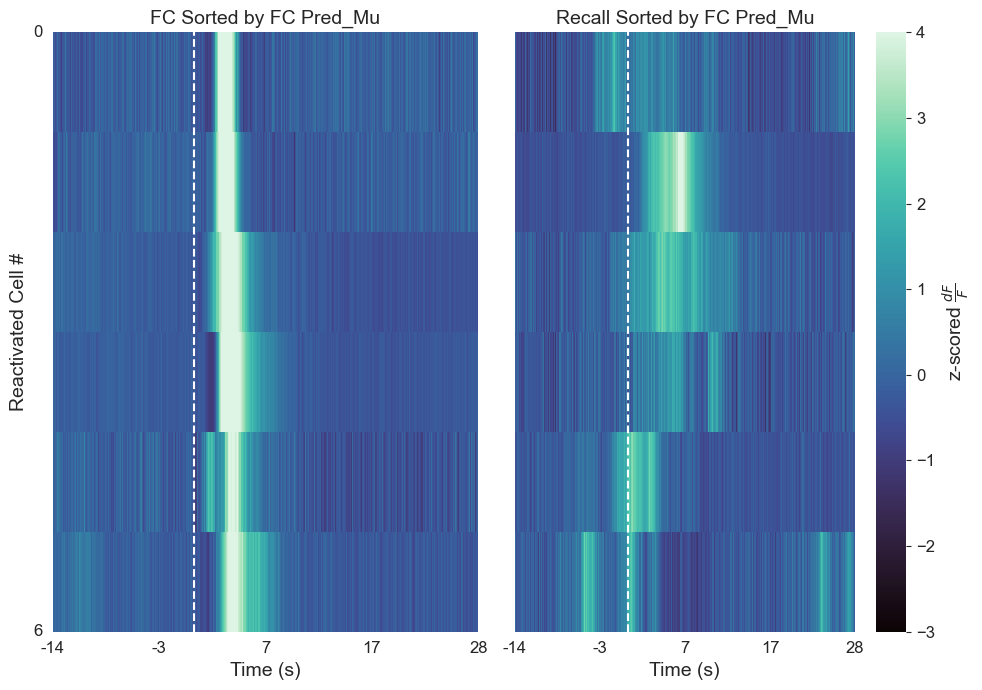

In [1095]:
# Extract first and last index for y-axis ticks
first_last_fc = [0, len(across_eta_fc_sorted)]
first_last_recall = [0, len(across_eta_recall_sorted)]

# Set up FacetGrid for plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 7),sharey=True)  # Adjust figsize as needed

# Plot the FC sorted heatmap
sns.heatmap(across_eta_fc_sorted, cmap='mako', cbar=False, ax=axs[0], vmin=-3, vmax=4, annot=False)
axs[0].axvline((time.shape[0] / 3), linestyle='--', color='white')
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].set_xticks(np.linspace(0, len(time), 5))
axs[0].set_xticklabels(np.linspace(np.min(time), np.max(time), 5).astype(int), rotation=0)
axs[0].set_yticks(first_last_fc)  # Set y-ticks to first and last indices
axs[0].set_yticklabels([first_last_fc[0], first_last_fc[1]], rotation=0)  # Label y-ticks
axs[0].set_title('FC Sorted by FC Pred_Mu', fontsize=14)
axs[0].set_xlabel('Time (s)', fontsize=14)
axs[0].set_ylabel('Reactivated Cell #', fontsize=14)

# Plot the Recall sorted heatmap
heatmap = sns.heatmap(across_eta_recall_sorted, cmap='mako', cbar=True, vmin=-3, vmax=4,cbar_kws={"label": r"z-scored $\frac{dF}{F}$"}, ax=axs[1], annot=False)
axs[1].axvline((time_R.shape[0] / 3), linestyle='--', color='white')
axs[1].tick_params(axis='both', which='major', labelsize=12)
axs[1].set_xticks(np.linspace(0, len(time_R), 5))
axs[1].set_xticklabels(np.linspace(np.min(time_R), np.max(time_R), 5).astype(int), rotation=0)
axs[1].set_yticks(first_last_recall)  # Set y-ticks to first and last indices
axs[1].set_yticklabels([first_last_recall[0], first_last_recall[1]], rotation=0)  # Label y-ticks
axs[1].set_title('Recall Sorted by FC Pred_Mu', fontsize=14)
axs[1].set_xlabel('Time (s)', fontsize=14)

# Get the current colorbar object from the heatmap
cbar = heatmap.collections[0].colorbar

# Set font size for colorbar labels
cbar.ax.yaxis.set_tick_params(labelsize=12)
cbar.set_label(r"z-scored $\frac{dF}{F}$", fontsize=14)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('/Users/suthardr/Desktop/astro9_reactivated_sort_sequence_PREDMU.png')